In [ ]:
import os
from scipy.io import loadmat
from utils import save_tensor_as_image

dir = os.path.join(os.path.dirname(os.getcwd()), 'snow_dataset')
masks_dir_path = os.path.join(dir, 'mask_15k_20k')
mask_names = [file_name for file_name in sorted(os.listdir(masks_dir_path)) if
              file_name.endswith('.mat')]

import torch

for mask_name in mask_names:
    x = loadmat(os.path.join(masks_dir_path, mask_name))['inst_map']
    x = (x>=1).astype(int)
    x = torch.tensor(x, dtype=torch.float32).unsqueeze(0) 
    save_tensor_as_image(x, os.path.join(dir, 'mask'), mask_name.strip('seed').replace('.mat',''))
    


In [7]:
from snow_dataset_2 import SnowDatasetSupervisedLearning, SnowDatasetSupervisedLearningAugmented
from torchvision.transforms import ToPILImage
dataset = SnowDatasetSupervisedLearningAugmented()
img, mask = dataset[18208]

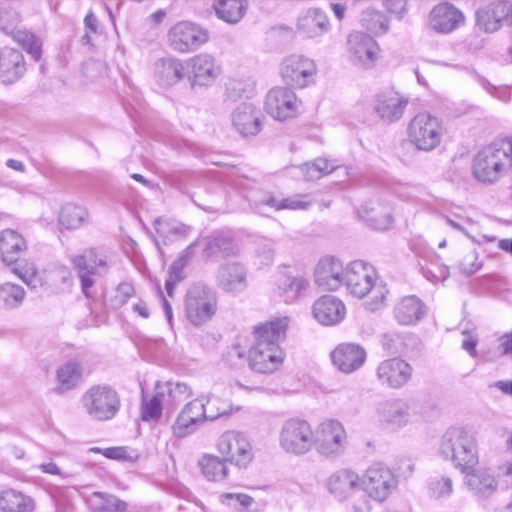

In [8]:
ToPILImage()(img)

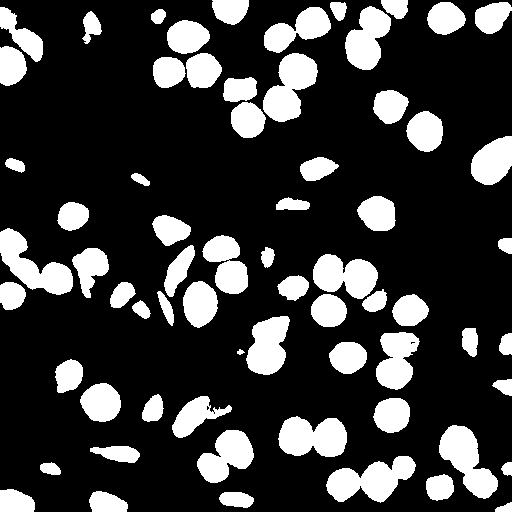

In [9]:
ToPILImage()(mask)